In [7]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.linalg import solve_triangular
import matplotlib.pyplot as plt

import gpjax as gpx

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_logdensity_and_grad_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import predictive_moments, posterior_function_draws

import blackjax
from blackjax.util import run_inference_algorithm

jax.config.update("jax_enable_x64", True)

In [2]:
key = jr.key(0)

n = 50
noise = 0.3

key, subkey = jr.split(key)
x_train = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x_train)
y_train = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x_train, y=y_train)

x_test = jnp.linspace(-3.5, 3.5, 200).reshape(-1, 1)
y_test = f(x_test)

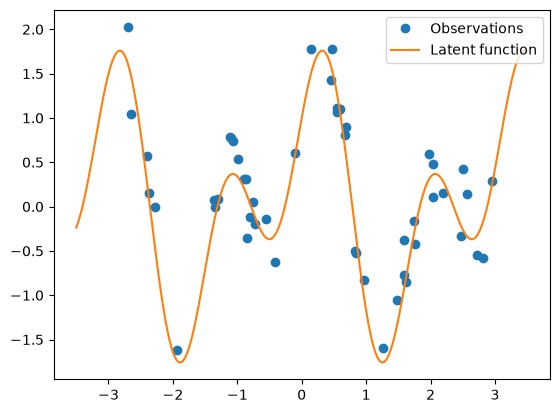

In [3]:
fig, ax = plt.subplots()
ax.plot(x_train, y_train, "o", label="Observations")
ax.plot(x_test, y_test, label="Latent function")
ax.legend(loc="best")
plt.show()

In [4]:
m = n   # number of basis functions
j = 30   # number of particles
jitter = 1e-5

k = gpx.kernels.Matern32(lengthscale=0.5)
K_train = k.gram(x_train).as_matrix()
train_basis = jnp.linalg.cholesky(K_train + jitter * jnp.eye(K_train.shape[0]))
position = jr.normal(key, (m, j))

pro_params = ProParameters(
    y=y_train,
    basis=train_basis,
    step_size=1e-3,
    nu=0.2,
    alpha=1.0,
    tolerance=1e-200,
    jitter=1e-5,
)

logdensity_fn = lambda z: pro_logdensity_fn(z, pro_params)

In [5]:
@jax.custom_vjp
def pro_logdensity_for_mala(z, parameters):
    return pro_logdensity_fn(z, parameters)

def pro_logdensity_fwd(z, parameters):
    value, grad = pro_logdensity_and_grad_fn(z, parameters)
    return value, grad

def pro_logdensity_bwd(grad, cotangent):
    return (cotangent * grad, None)

pro_logdensity_for_mala.defvjp(pro_logdensity_fwd, pro_logdensity_bwd)

In [20]:
mala = blackjax.mala(lambda z: pro_logdensity_for_mala(z, pro_params), 0.001)
state = mala.init(position)
state, info = mala.step(key, state)

In [29]:
final_state, history = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=mala,
    num_steps=40_000,
    initial_position=position,
)

In [17]:
ula = parametric_ula(pro_logdensity_fn, pro_params)
state = ula.init(position)
new_state, info = ula.step(key, state)

In [27]:
final_state, history = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=ula,
    num_steps=40_000,
    initial_position=position,
)

In [9]:
K_test_train = k.cross_covariance(x_test, x_train)
test_basis = solve_triangular(train_basis, K_test_train.T, lower=True).T
test_cov = k.gram(x_test).as_matrix()

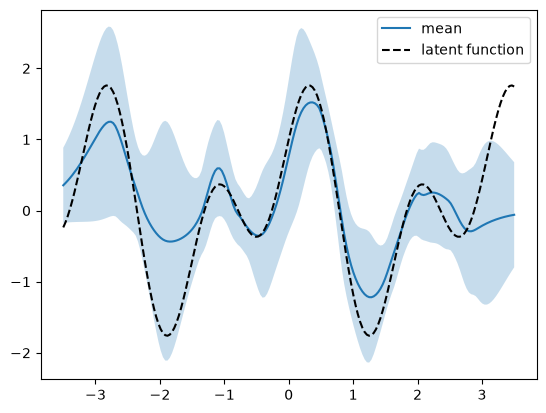

In [10]:
mean, std = predictive_moments(test_basis, final_state.position, noise_std=pro_params.nu)

x_plot = x_test.squeeze()

plt.plot(x_plot, mean, label="mean")
plt.fill_between(x_plot, mean - 1.64 * std, mean + 1.64 * std, alpha=0.25)
plt.plot(x_test.squeeze(), y_test.squeeze(), color="black", label="latent function", linestyle="--")
plt.legend()
plt.show()

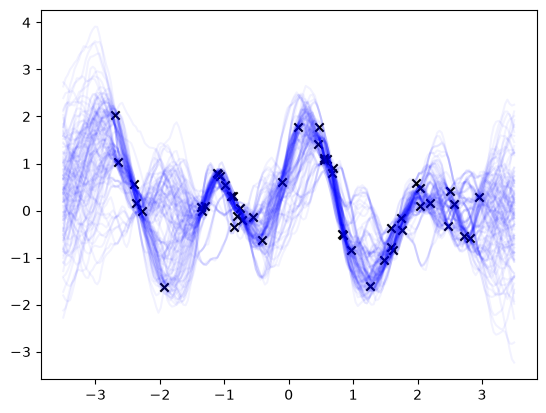

In [13]:
draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    final_state.position,
    num_draws=120,
    jitter=1e-6,
)

plt.plot(x_test.squeeze(), draws, color="blue", alpha=0.05)
plt.scatter(x_train.squeeze(), y_train.squeeze(), color="black", label="observations", marker="x")
plt.show()

## Benchmark: ULA vs MALA, autodiff vs hand-derived gradient

Compares wall-clock time per step for all four combinations of {ULA, MALA} x
{autodiff gradient, hand-derived gradient}. The hand-derived gradient is
routed through `pro_logdensity_for_mala`'s `custom_vjp`, so the backward pass
uses `pro_logdensity_and_grad_fn` instead of `jax.grad`.

In [30]:
import time


def benchmark(algorithm, num_steps=5_000, num_repeats=5):
    """Time `num_steps` of `algorithm`, returning the best of `num_repeats` runs."""
    run = jax.jit(
        lambda k, pos: run_inference_algorithm(
            rng_key=k,
            inference_algorithm=algorithm,
            num_steps=num_steps,
            initial_position=pos,
        )
    )

    # warm-up: compile, don't time
    final_state, _ = run(key, position)
    jax.block_until_ready(final_state)

    times = []
    for _ in range(num_repeats):
        t0 = time.perf_counter()
        final_state, _ = run(key, position)
        jax.block_until_ready(final_state)
        times.append(time.perf_counter() - t0)
    return min(times)

In [31]:
num_steps = 5_000

algorithms = {
    "MALA (autodiff)": blackjax.mala(
        lambda z: pro_logdensity_fn(z, pro_params), pro_params.step_size
    ),
    "MALA (hand-derived)": blackjax.mala(
        lambda z: pro_logdensity_for_mala(z, pro_params), pro_params.step_size
    ),
    "ULA (autodiff)": parametric_ula(pro_logdensity_fn, pro_params),
    "ULA (hand-derived)": parametric_ula(pro_logdensity_for_mala, pro_params),
}

results = {name: benchmark(alg, num_steps=num_steps) for name, alg in algorithms.items()}

for name, t in results.items():
    print(f"{name:22s} {t * 1e3:8.2f} ms total  {t / num_steps * 1e6:8.2f} us/step")

MALA (autodiff)          422.12 ms total     84.42 us/step
MALA (hand-derived)      452.57 ms total     90.51 us/step
ULA (autodiff)           384.84 ms total     76.97 us/step
ULA (hand-derived)       438.47 ms total     87.69 us/step
